# BTC/USDT Market Maker — Backtest Analysis
Loads a session parquet, computes standard and MM-specific metrics, and produces diagnostic plots.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f8f8',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.size':        11,
})

SESSION = '../data/btcusdt_1778599275.parquet'
df = pd.read_parquet(SESSION)
df['ts'] = pd.to_datetime(df['timestamp'], unit='ms')
df = df.set_index('ts').sort_index()
print(f'Loaded {len(df)} rows  |  {df.index[0]}  →  {df.index[-1]}')
df.head(3)

Loaded 1700 rows  |  2026-05-12 15:21:16.743000  →  2026-05-12 15:49:40.224000


,timestamp,bid_0_price,ask_0_price,mid,spread,microprice,obi,tfi,alpha,fair,half_spread,quote_bid,quote_ask,inventory,pnl,vol_10s,vol_60s,vol_5m
ts,,,,,,,,,,,,,,,,,,
2026-05-12 15:21:16.743,1778599276743,80546.42,80546.43,80546.425,0.01,80546.420406,-0.941656,-1.000000,-0.919686,80472.347577,2.902732,80469.5,80475.5,0.0,0.0,0.000001,0.000001,0.000001
2026-05-12 15:21:17.742,1778599277742,80546.42,80546.43,80546.425,0.01,80546.421228,-0.820833,0.880000,-0.011099,80545.531012,2.662732,80543.0,80548.0,0.0,0.0,0.000001,0.000001,0.000001
2026-05-12 15:21:18.741,1778599278741,80546.42,80546.43,80546.425,0.01,80546.421228,-0.820820,0.475728,-0.193015,80530.878320,1.854188,80529.0,80532.5,0.0,0.0,0.000001,0.000001,0.000001


## 1  Core performance metrics

In [4]:
def sharpe(pnl: np.ndarray) -> float:
    r = np.diff(pnl)
    return 0.0 if len(r) < 2 or r.std() == 0 else r.mean() / r.std()

def sortino(pnl: np.ndarray) -> float:
    """Like Sharpe but penalises only downside deviations."""
    r = np.diff(pnl)
    down = r[r < 0]
    return 0.0 if len(down) < 2 or down.std() == 0 else r.mean() / down.std()

def max_drawdown(pnl: np.ndarray) -> float:
    peak = np.maximum.accumulate(pnl)
    return float((pnl - peak).min())

def drawdown_curve(pnl: np.ndarray) -> np.ndarray:
    peak = np.maximum.accumulate(pnl)
    return pnl - peak

def calmar(pnl: np.ndarray) -> float:
    """Return / |MaxDD|.  Rewards strategies that earn without deep holes."""
    mdd = abs(max_drawdown(pnl))
    return 0.0 if mdd == 0 else (pnl[-1] - pnl[0]) / mdd

def profit_factor(pnl: np.ndarray) -> float:
    """Gross profit / gross loss.  >1 means profitable, >2 is strong."""
    r = np.diff(pnl)
    g, l = r[r > 0].sum(), abs(r[r < 0].sum())
    return 0.0 if l == 0 else g / l

pnl = df['pnl'].values
inv = df['inventory'].values

metrics = {
    'Final PnL':        f'{pnl[-1]:+.4f}',
    'Sharpe':           f'{sharpe(pnl):.4f}',
    'Sortino':          f'{sortino(pnl):.4f}',
    'Calmar':           f'{calmar(pnl):.4f}',
    'Max Drawdown':     f'{max_drawdown(pnl):.4f}',
    'Profit Factor':    f'{profit_factor(pnl):.4f}',
}
print('\n=== Core metrics ===')
for k, v in metrics.items():
    print(f'  {k:<20}: {v}')


=== Core metrics ===
  Final PnL           : -69.3280
  Sharpe              : -0.0950
  Sortino             : -0.1118
  Calmar              : -0.8134
  Max Drawdown        : -85.2350
  Profit Factor       : 0.6557


## 2  Market-maker specific metrics

In [5]:
# --- fill rate ---------------------------------------------------------
inv_delta = np.abs(np.diff(inv))
fills      = int((inv_delta > 1e-9).sum())   # cycles where inventory moved
orders     = len(df) * 2                     # 1 bid + 1 ask per row
fill_rate  = fills / orders if orders > 0 else 0.0

# --- inventory turnover ------------------------------------------------
# total BTC volume traded (round-trips count once per leg)
turnover = inv_delta.sum()

# --- zero crossings: how often inventory flips sign -------------------
sign_changes = int(((np.sign(inv[1:]) * np.sign(inv[:-1])) < 0).sum())

# --- time at max inventory (% of session blocked) ---------------------
MAX_INV = 0.1   # from config
time_at_max = float((np.abs(inv) >= MAX_INV).mean())

# --- spread capture: $ earned per fill --------------------------------
# Spread income ≈ half_spread × filled size per cycle
# We proxy it from PnL changes on cycles where inventory returned toward 0
pnl_per_inv_unit = np.where(
    inv_delta > 1e-9,
    np.abs(np.diff(pnl)) / inv_delta,
    np.nan
)
avg_spread_capture = np.nanmedian(pnl_per_inv_unit)

# --- adverse selection: mid move in the 5s after a fill ---------------
# Positive = mid moved against us (we bought, then mid fell)
horizon = 5   # rows (≈ seconds)
fill_idx = np.where(inv_delta > 1e-9)[0]
adverse = []
for i in fill_idx:
    if i + horizon < len(df):
        direction = np.sign(inv[i+1] - inv[i])   # +1 bought, -1 sold
        mid_move  = df['mid'].values[i+horizon] - df['mid'].values[i]
        adverse.append(-direction * mid_move)    # positive = bad
avg_adverse = float(np.mean(adverse)) if adverse else 0.0

mm_metrics = {
    'Fill Rate':              f'{fill_rate:.4f}',
    'Inventory Turnover':     f'{turnover:.4f} BTC',
    'Zero Crossings':         str(sign_changes),
    'Time at Max Inv':        f'{time_at_max:.1%}',
    'Avg Spread Capture':     f'{avg_spread_capture:.4f} $/BTC',
    'Avg Adverse Selection':  f'{avg_adverse:.4f} $ (5s horizon)',
}
print('\n=== Market-maker metrics ===')
for k, v in mm_metrics.items():
    print(f'  {k:<26}: {v}')


=== Market-maker metrics ===
  Fill Rate                 : 0.0835
  Inventory Turnover        : 2.8400 BTC
  Zero Crossings            : 0
  Time at Max Inv           : 21.8%
  Avg Spread Capture        : 34.7736 $/BTC
  Avg Adverse Selection     : -4.0087 $ (5s horizon)


/var/folders/zk/2p1tzxbd6ysfl4_7650h0jbw0000gp/T/ipykernel_21892/268324419.py:23: RuntimeWarning: divide by zero encountered in divide
  np.abs(np.diff(pnl)) / inv_delta,
/var/folders/zk/2p1tzxbd6ysfl4_7650h0jbw0000gp/T/ipykernel_21892/268324419.py:23: RuntimeWarning: invalid value encountered in divide
  np.abs(np.diff(pnl)) / inv_delta,


## 3  PnL decomposition

Breaks total PnL into three sources:
- **Spread income** — captured half-spread on each round-trip  
- **Inventory PnL** — mark-to-market gain/loss on open position  
- **Fee drag** — total fees paid

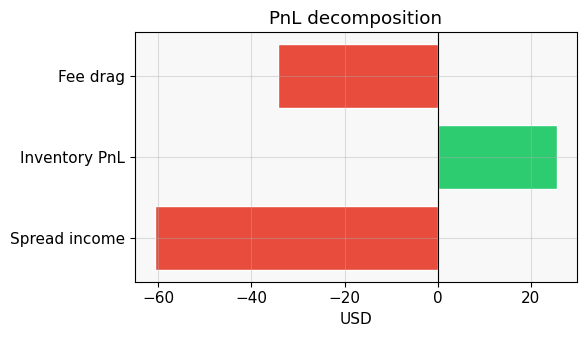

  Spread income : -60.6775
  Inventory PnL : +25.5750
  Fee drag      : -34.2254
  Total         : -69.3280


In [6]:
FEE_BPS  = 1.5 / 10_000
QUOTE_SZ = 0.01

# fee drag: each fill pays fee_bps × notional
total_fees = fills * QUOTE_SZ * df['mid'].mean() * FEE_BPS

# inventory PnL: inventory × (final_mid − entry_mid)
# simplification: use last mid vs first mid scaled by avg inventory
inv_pnl = float(inv[-1] * (df['mid'].values[-1] - df['mid'].values[0]))

# spread income is the residual
spread_income = pnl[-1] - inv_pnl + total_fees

fig, ax = plt.subplots(figsize=(6, 3.5))
components = ['Spread income', 'Inventory PnL', 'Fee drag']
values     = [spread_income, inv_pnl, -total_fees]
colors     = ['#2ecc71' if v >= 0 else '#e74c3c' for v in values]
ax.barh(components, values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('PnL decomposition')
ax.set_xlabel('USD')
plt.tight_layout()
plt.show()
print(f'  Spread income : {spread_income:+.4f}')
print(f'  Inventory PnL : {inv_pnl:+.4f}')
print(f'  Fee drag      : {-total_fees:+.4f}')
print(f'  Total         : {pnl[-1]:+.4f}')

## 4  Main dashboard — PnL, drawdown, inventory, vol

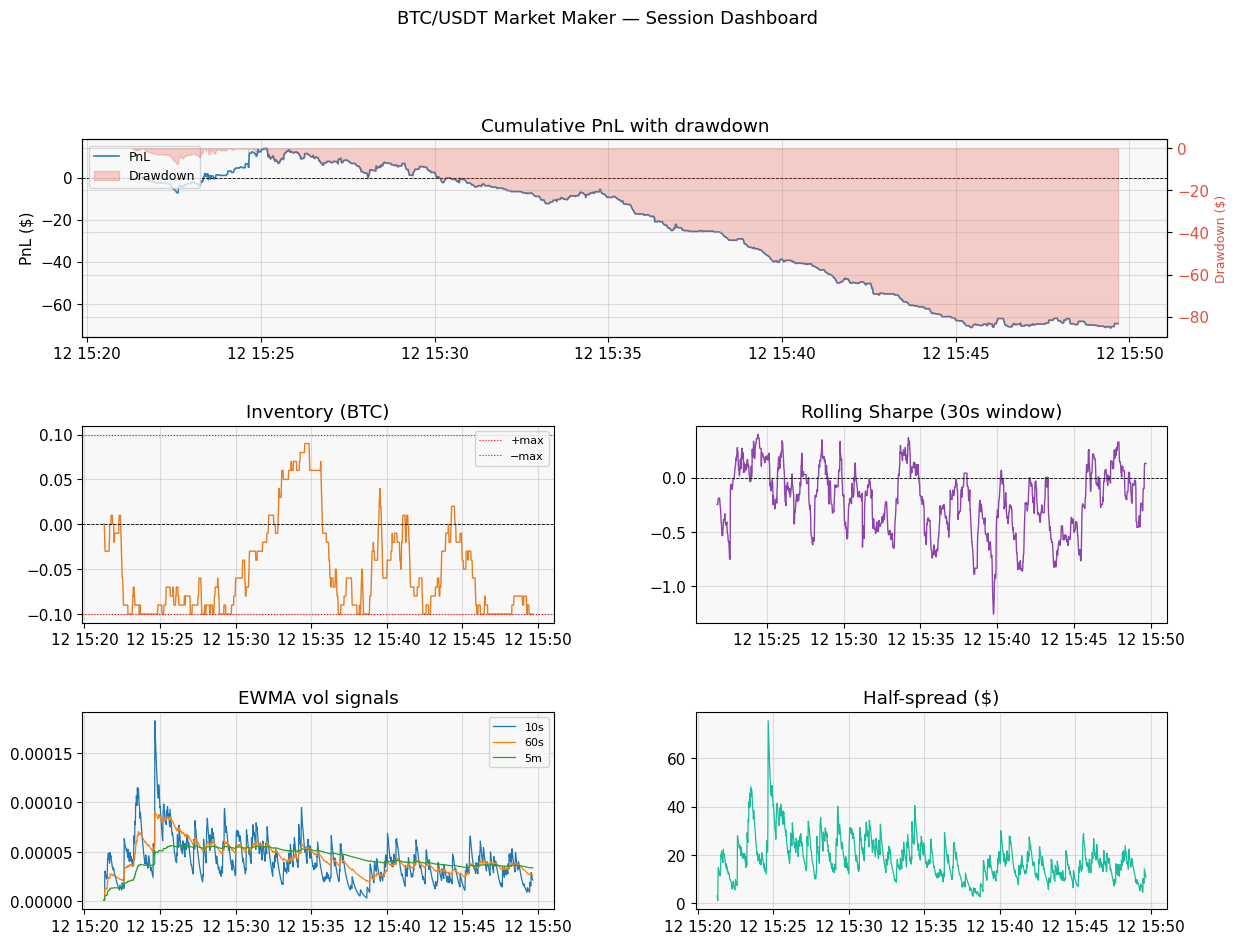

In [7]:
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)

# -- PnL + drawdown overlay --
ax1 = fig.add_subplot(gs[0, :])
ax1b = ax1.twinx()
ax1.plot(df.index, pnl, color='#2980b9', linewidth=1.2, label='PnL')
ax1.axhline(0, color='black', linewidth=0.6, linestyle='--')
ax1b.fill_between(df.index, drawdown_curve(pnl), 0,
                  color='#e74c3c', alpha=0.25, label='Drawdown')
ax1b.set_ylabel('Drawdown ($)', color='#e74c3c', fontsize=9)
ax1b.tick_params(axis='y', labelcolor='#e74c3c')
ax1.set_ylabel('PnL ($)')
ax1.set_title('Cumulative PnL with drawdown')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

# -- Inventory --
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(df.index, inv, color='#e67e22', linewidth=1.0)
ax2.axhline(0, color='black', linewidth=0.6, linestyle='--')
ax2.axhline( MAX_INV, color='red', linewidth=0.8, linestyle=':', label='+max')
ax2.axhline(-MAX_INV, color='red', linewidth=0.8, linestyle=':', label='−max')
ax2.set_title('Inventory (BTC)')
ax2.legend(fontsize=8)

# -- Rolling Sharpe (30-row window) --
ax3 = fig.add_subplot(gs[1, 1])
roll_ret = df['pnl'].diff().fillna(0)
roll_sr  = roll_ret.rolling(30).mean() / (roll_ret.rolling(30).std() + 1e-12)
ax3.plot(df.index, roll_sr, color='#8e44ad', linewidth=1.0)
ax3.axhline(0, color='black', linewidth=0.6, linestyle='--')
ax3.set_title('Rolling Sharpe (30s window)')

# -- Vol signals --
ax4 = fig.add_subplot(gs[2, 0])
ax4.plot(df.index, df['vol_10s'], label='10s',  linewidth=0.9)
ax4.plot(df.index, df['vol_60s'], label='60s',  linewidth=0.9)
ax4.plot(df.index, df['vol_5m'],  label='5m',   linewidth=0.9)
ax4.set_title('EWMA vol signals')
ax4.legend(fontsize=8)

# -- Half-spread over time --
ax5 = fig.add_subplot(gs[2, 1])
ax5.plot(df.index, df['half_spread'], color='#1abc9c', linewidth=0.9)
ax5.set_title('Half-spread ($)')

plt.suptitle('BTC/USDT Market Maker — Session Dashboard', fontsize=13, y=1.01)
plt.savefig('backtest_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

## 5  Adverse selection — TFI at fill time

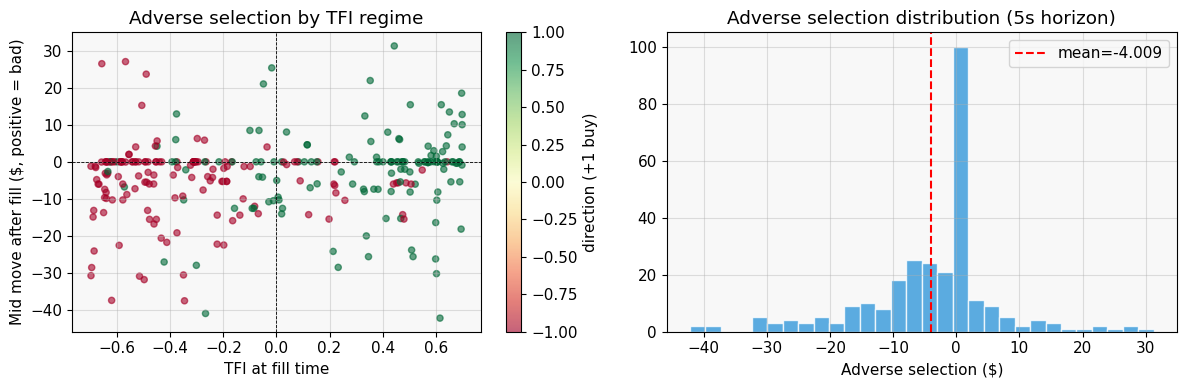

In [8]:
# TFI (trade flow imbalance) at the moment of each fill.
# Positive TFI = buy pressure; we expect bid fills to be worse (adverse).
fill_rows  = df.iloc[fill_idx] if len(fill_idx) else df.iloc[:0]
fill_dirs  = np.sign(inv[fill_idx + 1] - inv[fill_idx])   # +1 buy, -1 sell

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# scatter: TFI vs post-fill mid move
ax = axes[0]
if len(adverse) > 0:
    sc = ax.scatter(fill_rows['tfi'].values[:len(adverse)],
                    adverse, c=fill_dirs[:len(adverse)],
                    cmap='RdYlGn', alpha=0.6, s=20)
    plt.colorbar(sc, ax=ax, label='direction (+1 buy)')
ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
ax.axvline(0, color='black', linewidth=0.6, linestyle='--')
ax.set_xlabel('TFI at fill time')
ax.set_ylabel('Mid move after fill ($, positive = bad)')
ax.set_title('Adverse selection by TFI regime')

# histogram of adverse selection values
ax = axes[1]
if len(adverse) > 0:
    ax.hist(adverse, bins=30, color='#3498db', edgecolor='white', alpha=0.8)
    ax.axvline(np.mean(adverse), color='red', linestyle='--',
               label=f'mean={np.mean(adverse):.3f}')
ax.set_xlabel('Adverse selection ($)')
ax.set_title('Adverse selection distribution (5s horizon)')
ax.legend()

plt.tight_layout()
plt.show()

## 6  Quote quality — bid/ask vs mid

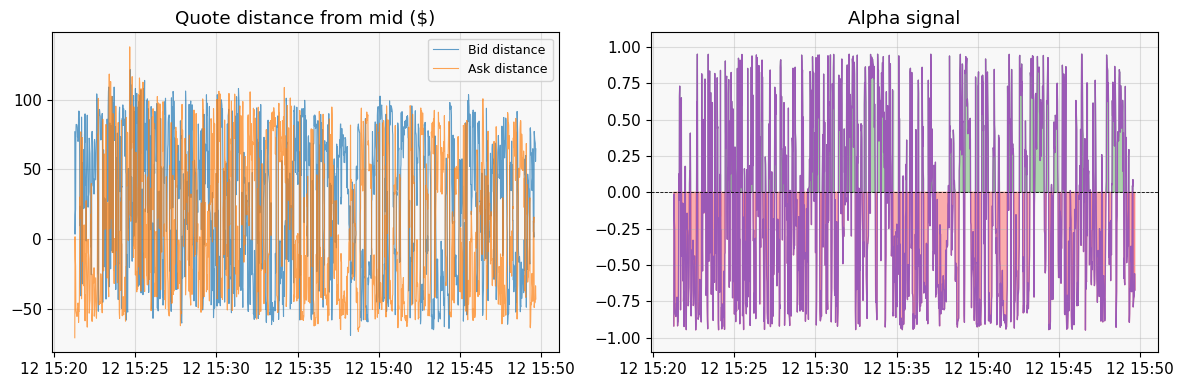

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# quote distance from mid
bid_dist = df['mid'] - df['quote_bid']
ask_dist = df['quote_ask'] - df['mid']

ax = axes[0]
ax.plot(df.index, bid_dist, label='Bid distance', alpha=0.7, linewidth=0.8)
ax.plot(df.index, ask_dist, label='Ask distance', alpha=0.7, linewidth=0.8)
ax.set_title('Quote distance from mid ($)')
ax.legend(fontsize=9)

# alpha signal over time
ax = axes[1]
ax.plot(df.index, df['alpha'], color='#9b59b6', linewidth=0.9)
ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
ax.fill_between(df.index, df['alpha'], 0,
                where=(df['alpha'] > 0), alpha=0.3, color='green')
ax.fill_between(df.index, df['alpha'], 0,
                where=(df['alpha'] < 0), alpha=0.3, color='red')
ax.set_title('Alpha signal')
ax.set_ylim(-1.1, 1.1)

plt.tight_layout()
plt.show()

## 7  Inventory distribution & zero-crossing rate

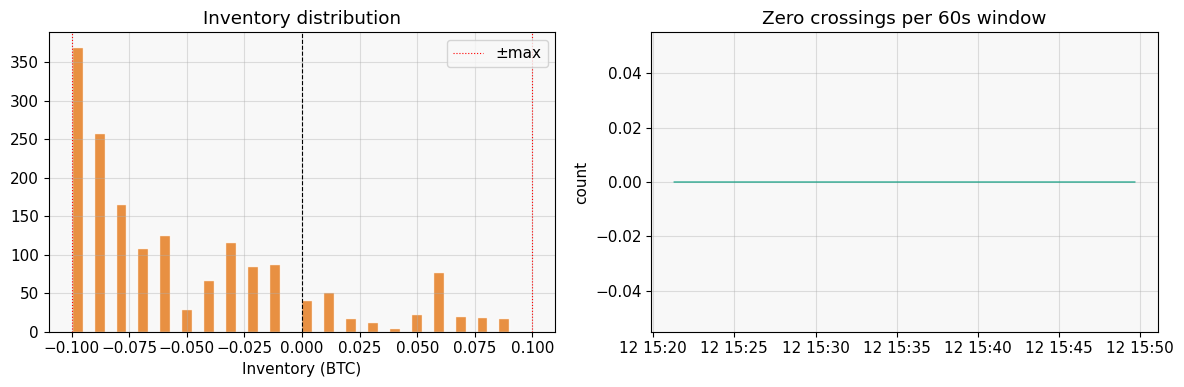

Total zero crossings : 0
Avg crossings / min  : 0.00


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(inv, bins=40, color='#e67e22', edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline( MAX_INV, color='red', linewidth=0.8, linestyle=':', label='±max')
ax.axvline(-MAX_INV, color='red', linewidth=0.8, linestyle=':')
ax.set_xlabel('Inventory (BTC)')
ax.set_title('Inventory distribution')
ax.legend()

# rolling zero-crossing rate (how many sign flips per minute)
ax = axes[1]
sign_flip = (np.sign(inv[1:]) * np.sign(inv[:-1]) < 0).astype(float)
roll_zc   = pd.Series(sign_flip, index=df.index[1:]).rolling('60s').sum()
ax.plot(df.index[1:], roll_zc, color='#16a085', linewidth=0.9)
ax.set_title('Zero crossings per 60s window')
ax.set_ylabel('count')

plt.tight_layout()
plt.show()
print(f'Total zero crossings : {sign_changes}')
print(f'Avg crossings / min  : {sign_changes / max((df.index[-1]-df.index[0]).seconds/60, 1):.2f}')

## 8  Full metrics summary

In [11]:
duration_s = (df.index[-1] - df.index[0]).total_seconds()

print('\n' + '='*48)
print('  BTC/USDT MARKET MAKER — BACKTEST SUMMARY')
print('='*48)
print(f'  Session duration  : {duration_s/60:.1f} min ({len(df)} rows)')
print()
print('  --- Performance ---')
print(f'  Final PnL         : {pnl[-1]:+.4f}')
print(f'  Sharpe            : {sharpe(pnl):.4f}')
print(f'  Sortino           : {sortino(pnl):.4f}')
print(f'  Calmar            : {calmar(pnl):.4f}')
print(f'  Profit Factor     : {profit_factor(pnl):.4f}')
print(f'  Max Drawdown      : {max_drawdown(pnl):.4f}')
print()
print('  --- Market Making ---')
print(f'  Fill Rate         : {fill_rate:.4f}')
print(f'  Inv Turnover      : {turnover:.4f} BTC')
print(f'  Zero Crossings    : {sign_changes}')
print(f'  Time at Max Inv   : {time_at_max:.1%}')
print(f'  Spread Capture    : {avg_spread_capture:.4f} $/BTC')
print(f'  Adverse Selection : {avg_adverse:.4f} $ (5s)')
print()
print('  --- PnL Decomposition ---')
print(f'  Spread income     : {spread_income:+.4f}')
print(f'  Inventory PnL     : {inv_pnl:+.4f}')
print(f'  Fee drag          : {-total_fees:+.4f}')
print('='*48)


  BTC/USDT MARKET MAKER — BACKTEST SUMMARY
  Session duration  : 28.4 min (1700 rows)

  --- Performance ---
  Final PnL         : -69.3280
  Sharpe            : -0.0950
  Sortino           : -0.1118
  Calmar            : -0.8134
  Profit Factor     : 0.6557
  Max Drawdown      : -85.2350

  --- Market Making ---
  Fill Rate         : 0.0835
  Inv Turnover      : 2.8400 BTC
  Zero Crossings    : 0
  Time at Max Inv   : 21.8%
  Spread Capture    : 34.7736 $/BTC
  Adverse Selection : -4.0087 $ (5s)

  --- PnL Decomposition ---
  Spread income     : -60.6775
  Inventory PnL     : +25.5750
  Fee drag          : -34.2254
